In [ ]:
# Install required packages into the active kernel if they are not already present.
# This ensures the notebook runs correctly regardless of which Python kernel is selected.
# spip install --quiet pandas requests scipy matplotlib plotly

# Ethiopia Electricity Analysis

**Author:** Netsanet Worku  
**Institution:** Madda Walabu University  
**Date:** 2025-07-11  

This notebook documents the full end-to-end analysis of Ethiopia's electricity sector
using World Bank open data. The workflow covers data collection, data cleaning,
trend analysis, visualization, and report generation.

In [10]:
import sys
import os
import asyncio

# Fix for Windows: nbconvert uses the Proactor event loop which does not
# support the selector-based operations that ZMQ/tornado need. Switching to
# the Selector policy avoids the RuntimeWarning and prevents kernel hangs.
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

# Locate the project root (one level up from notebooks/) and add it to sys.path
# so that `import config` and `from src.<module> import ...` resolve correctly
# regardless of the current working directory when the notebook is opened.
_NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.path.abspath('')
_PROJECT_ROOT = os.path.abspath(os.path.join(_NOTEBOOK_DIR, ".."))
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

import config
from src.data_collector import collect_all
from src.data_cleaner import clean_and_merge
from src.trend_analyzer import analyze
from src.visualizer import generate_all_charts
from src.report_generator import generate_report
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)

C:\Users\Netsanet\AppData\Local\Temp\ipykernel_174896\898147158.py:9: DeprecationWarning: 'asyncio.WindowsSelectorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
C:\Users\Netsanet\AppData\Local\Temp\ipykernel_174896\898147158.py:9: DeprecationWarning: 'asyncio.set_event_loop_policy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())


## Data Collection

In this step, raw indicator data is fetched from the **World Bank Open Data API** for Ethiopia.
Two indicators are collected:

- **EG.USE.ELEC.KH.PC** — Electric power consumption (kWh per capita)
- **EG.ELC.ACCS.ZS** — Access to electricity (% of population)

The `collect_all` function queries the World Bank JSON REST API for each indicator
and saves the raw responses as CSV files in `data/raw/`. If the API is unreachable,
the module automatically falls back to local CSV files stored in the same directory.

In [11]:
raw_frames = collect_all(config)
for name, df_raw in raw_frames.items():
    print(f"{name}: shape={df_raw.shape}")
raw_frames[next(iter(raw_frames))].head()

INFO:src.data_collector:[data_collector.collect_all] Saved raw data for indicator 'EG.USE.ELEC.KH.PC' to 'e:\Intership\Intership_2026_EEU\Ethiopian_EU\ethiopia-electricity-analysis\data/raw\EG.USE.ELEC.KH.PC.csv'.
INFO:src.data_collector:[data_collector.collect_all] Saved raw data for indicator 'EG.ELC.ACCS.ZS' to 'e:\Intership\Intership_2026_EEU\Ethiopian_EU\ethiopia-electricity-analysis\data/raw\EG.ELC.ACCS.ZS.csv'.


consumption: shape=(34, 2)
access: shape=(24, 2)


,year,EG.USE.ELEC.KH.PC
0,2023,112.555828
1,2022,95.649944
2,2021,83.880125
3,2020,93.383935
4,2019,92.312438


## Data Cleaning

The raw indicator DataFrames are merged and cleaned in this step using `clean_and_merge`.
The cleaning process performs the following operations:

1. **Outer join** both indicator DataFrames on the `year` column so no years are lost.
2. **Rename columns** from raw World Bank indicator codes to human-readable names:
   `consumption_kwh_per_capita` and `access_pct_of_population`.
3. **Type casting** — `year` to integer; value columns to float.
4. **Drop rows** where both indicator values are NaN (no useful data).
5. **Flag rows** with negative values in a boolean `flagged` column.
6. **Sort ascending** by year.
7. **Save** the cleaned dataset to `data/processed/ethiopia_electricity_cleaned.csv`.

In [12]:
df = clean_and_merge(raw_frames)
display(df.head())
df.describe()

INFO:src.data_cleaner:[data_cleaner.clean_and_merge] Saved cleaned dataset (34 rows) to 'e:\Intership\Intership_2026_EEU\Ethiopian_EU\ethiopia-electricity-analysis\data\processed\ethiopia_electricity_cleaned.csv'.


,year,consumption_kwh_per_capita,access_pct_of_population,flagged
0,1990,22.726435,NaN,False
1,1991,21.883776,NaN,False
2,1992,21.541356,NaN,False
3,1993,23.180520,NaN,False
4,1994,23.484348,NaN,False


,year,consumption_kwh_per_capita,access_pct_of_population
count,34.000000,34.000000,24.000000
mean,2006.500000,47.885107,30.112500
std,9.958246,28.308414,15.334681
min,1990.000000,21.541356,10.200000
25%,1998.250000,23.717096,17.750000
50%,2006.500000,36.901733,26.350000
75%,2014.750000,71.753131,44.425000
max,2023.000000,112.555828,55.400000


## Trend Analysis

Trend analysis is performed using the `analyze` function from `trend_analyzer`.
This step computes the following statistics for each indicator:

- **Descriptive statistics**: mean, median, minimum, maximum, standard deviation.
- **Peak and low years**: the calendar year with the highest and lowest recorded value.
- **Year-over-year percentage change**: how each indicator changed relative to the previous year.
- **Linear regression**: a least-squares trend line fitted to non-NaN data points
  (requires at least 5 valid data points; otherwise skipped with a warning).

All summary statistics are saved to `data/processed/ethiopia_electricity_summary.csv`.

In [13]:
results = analyze(df, config)
summary_data = results["summary"]
summary_df = pd.DataFrame(summary_data).T
display(summary_df)

INFO:src.trend_analyzer:[trend_analyzer.compute_summary] 'consumption_kwh_per_capita' — mean=47.8851, median=36.9017, min=21.5414, max=112.5558, std=28.3084, nan_count=0, peak_year=2023, low_year=1992
INFO:src.trend_analyzer:[trend_analyzer.compute_summary] 'access_pct_of_population' — mean=30.1125, median=26.3500, min=10.2000, max=55.4000, std=15.3347, nan_count=10, peak_year=2022, low_year=2001
INFO:src.trend_analyzer:[trend_analyzer.compute_yoy_change] Added 'consumption_yoy_pct' column.
INFO:src.trend_analyzer:[trend_analyzer.compute_yoy_change] Added 'access_yoy_pct' column.
INFO:src.trend_analyzer:[trend_analyzer.fit_linear_trend] 'consumption_kwh_per_capita' — slope=2.636169, intercept=-5241.5886, r_squared=0.8600
INFO:src.trend_analyzer:[trend_analyzer.fit_linear_trend] 'access_pct_of_population' — slope=2.104826, intercept=-4203.7452, r_squared=0.9420
INFO:src.trend_analyzer:[trend_analyzer.analyze] Summary CSV saved to 'e:\Intership\Intership_2026_EEU\Ethiopian_EU\ethiopia-el

,mean,median,min,max,std,nan_count,peak_year,low_year
consumption_kwh_per_capita,47.885107,36.901733,21.541356,112.555828,28.308414,0.0,2023.0,1992.0
access_pct_of_population,30.112500,26.350000,10.200000,55.400000,15.334681,10.0,2022.0,2001.0


## Visualization

Line charts are generated for each indicator using `generate_all_charts`.
Each chart shows the indicator value on the y-axis plotted over time (year on the x-axis),
with labeled axes and a descriptive title.

Where a linear regression trend is available, the trend line is overlaid on the chart
as a dashed red line to visually communicate the overall direction of change.

Charts are saved as PNG files in the `charts/` directory and displayed inline below.

INFO:src.visualizer:[visualizer.plot_indicator] Chart saved: 'e:\Intership\Intership_2026_EEU\Ethiopian_EU\ethiopia-electricity-analysis\src\..\charts\consumption_kwh_per_capita.png'.
INFO:src.visualizer:[visualizer.plot_indicator] Chart saved: 'e:\Intership\Intership_2026_EEU\Ethiopian_EU\ethiopia-electricity-analysis\src\..\charts\access_pct_of_population.png'.


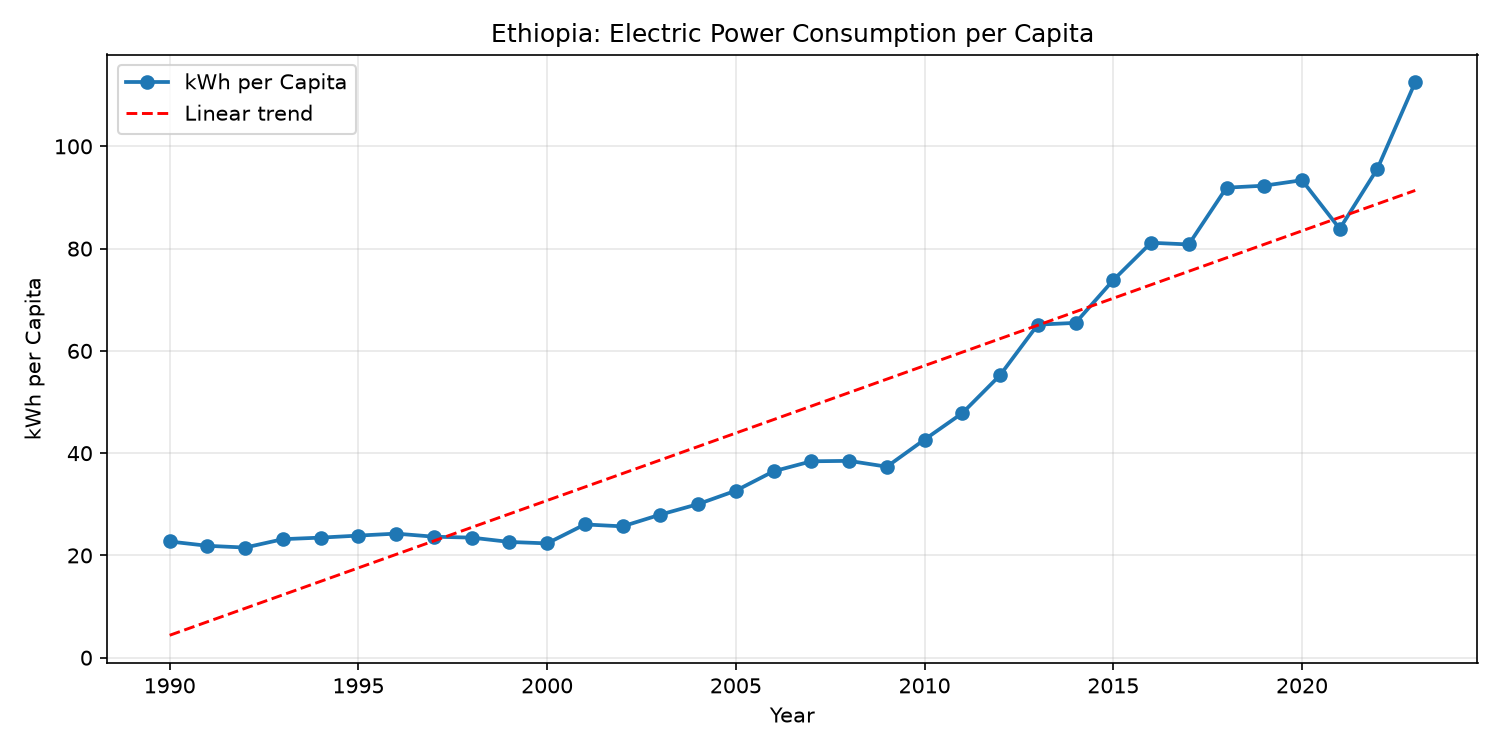

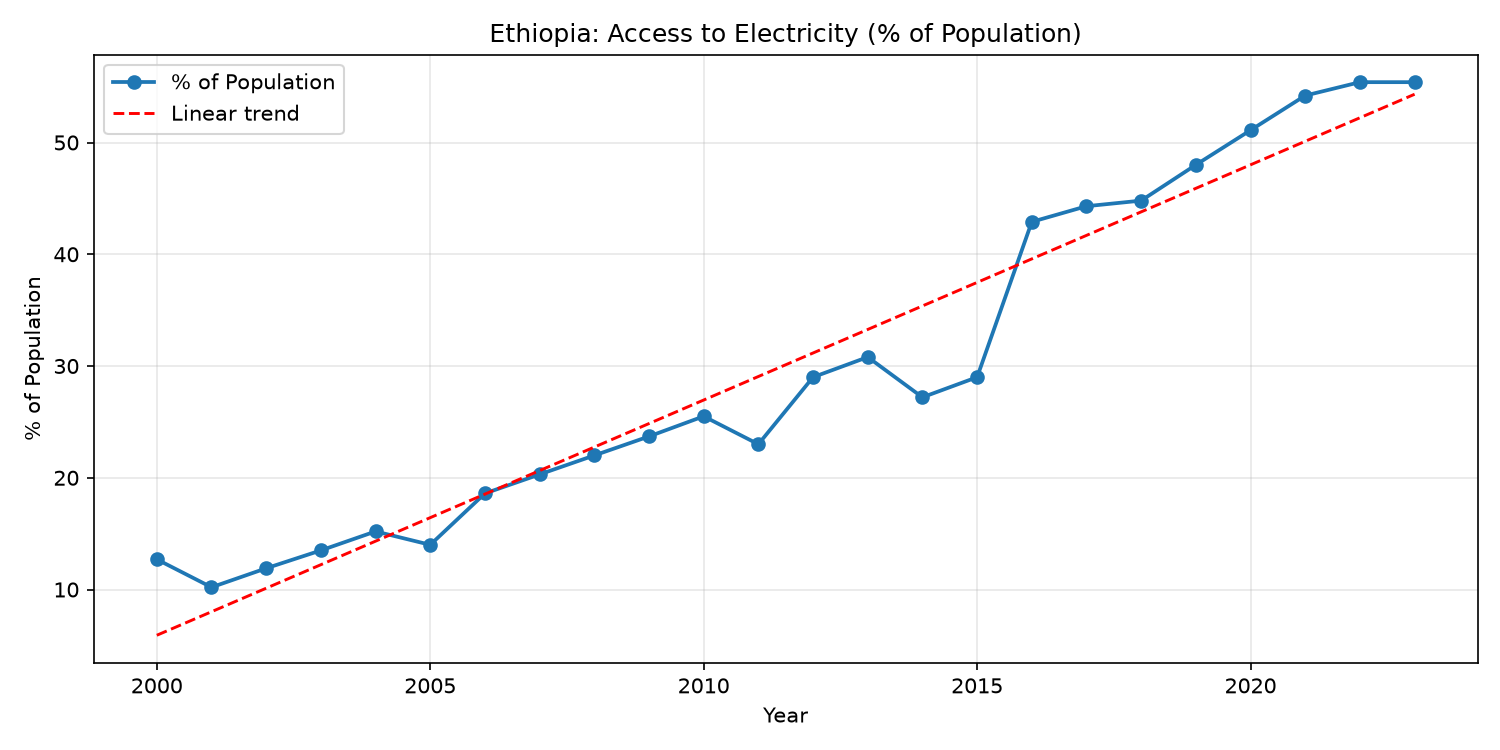

In [14]:
from IPython.display import display as ipy_display, Image

generate_all_charts(df, results, config)

# Display the saved charts inline
_charts_dir = os.path.join(_PROJECT_ROOT, "charts")
for fname in ["consumption_kwh_per_capita.png", "access_pct_of_population.png"]:
    chart_path = os.path.join(_charts_dir, fname)
    if os.path.exists(chart_path):
        ipy_display(Image(chart_path))

## Report Generation

A structured Markdown report is generated from the analysis results using `generate_report`.
The report includes the following sections:

1. **Introduction** — Overview of the analysis objectives.
2. **Data Sources** — Full citation of World Bank indicators with access date.
3. **Methodology** — Description of each pipeline step.
4. **Key Findings** — Numeric values for mean, trend slope, and peak year per indicator.
5. **Visualizations** — References to the generated charts.
6. **Conclusion** — Summary of the overall findings.

The report is saved to `reports/ethiopia_electricity_report.md` and rendered inline below.

In [ ]:
from IPython.display import Markdown
report_md = generate_report(df, results, config)
display(Markdown(report_md))

## Conclusions

This notebook has demonstrated a complete end-to-end analysis of Ethiopia's electricity
sector using World Bank open data.

Key takeaways from the analysis:

- **Electric power consumption per capita** shows the historical trajectory of energy
  use in Ethiopia, with the linear trend revealing the overall direction of change
  over the studied period.
- **Access to electricity** reflects progress in rural electrification and infrastructure
  expansion, with the trend slope quantifying the average annual improvement in
  population coverage.
- NaN values in the World Bank data are handled transparently — statistics are computed
  on valid data only, and excluded row counts are documented in the summary output.
- The full pipeline is reproducible: re-running this notebook from top to bottom in a
  fresh kernel will re-fetch data (or load from local fallback files), re-clean,
  re-analyze, regenerate charts, and overwrite the report with updated results.

For a detailed written discussion of the findings, see
`reports/ethiopia_electricity_report.md`.